In [72]:
import json
import re
import math
import glob
import random
from collections import Counter
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

# Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [73]:
from pathlib import Path

BASE_DIR = Path.cwd() 

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("QA files:", len(list(DATA_DIR.glob("*_qa_dataset.json"))))
print("Test files:", len(list(DATA_DIR.glob("*_test_set.json"))))

DATA_DIR: /content/data
QA files: 7
Test files: 7


In [74]:
def normalize_arabic(text):
    text = re.sub(r'[^\w\s\u0600-\u06FF]', ' ', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

class QAVocabulary:
    def __init__(self, max_size=10000):
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3, "<SEP>": 4}
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>", 4: "<SEP>"}
        self.max_size = max_size
        self.word_counts = Counter()

    def build_vocab(self, texts):
        for text in texts:
            self.word_counts.update(text.split())
        for word, _ in self.word_counts.most_common(self.max_size - len(self.stoi)):
            if word not in self.stoi:
                idx = len(self.stoi)
                self.stoi[word] = idx
                self.itos[idx] = word

    def encode(self, text):
        return [self.stoi.get(word, self.stoi["<UNK>"]) for word in text.split()]

    def decode(self, ids):
        return " ".join([self.itos.get(int(idx), "<UNK>") for idx in ids if idx not in [0, 1, 2, 4]])

class ArabicQADataset(Dataset):
    def __init__(self, json_files, vocab, max_len=256, is_train=True):
        self.vocab = vocab
        self.max_len = max_len
        self.data = []
        all_texts = []
        if isinstance(json_files, str):
            json_files = [json_files]
        for file_path in json_files:
            with open(file_path, 'r', encoding='utf-8') as f:
                dataset = json.load(f)
            for article in dataset['data']:
                for paragraph in article['paragraphs']:
                    context = normalize_arabic(paragraph['context'])
                    for qa in paragraph['qas']:
                        question = normalize_arabic(qa['question'])
                        answer = normalize_arabic(qa['answers'][0]['text'])
                        self.data.append((question, context, answer))
                        all_texts.extend([question, context, answer])
        if is_train:
            self.vocab.build_vocab(all_texts)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        question, context, answer = self.data[idx]
        q_ids = self.vocab.encode(question)
        c_ids = self.vocab.encode(context)
        a_ids = self.vocab.encode(answer)
        
        src_seq = [self.vocab.stoi["<SOS>"]] + q_ids + [self.vocab.stoi["<SEP>"]] + c_ids + [self.vocab.stoi["<EOS>"]]
        tgt_seq = [self.vocab.stoi["<SOS>"]] + a_ids + [self.vocab.stoi["<EOS>"]]
        
        if len(src_seq) < self.max_len:
            src_seq += [self.vocab.stoi["<PAD>"]] * (self.max_len - len(src_seq))
        else:
            src_seq = src_seq[:self.max_len-1] + [self.vocab.stoi["<EOS>"]]
            
        if len(tgt_seq) < self.max_len:
            tgt_seq += [self.vocab.stoi["<PAD>"]] * (self.max_len - len(tgt_seq))
        else:
            tgt_seq = tgt_seq[:self.max_len-1] + [self.vocab.stoi["<EOS>"]]
            
        return torch.tensor(src_seq), torch.tensor(tgt_seq)

In [75]:
def exact_match(reference, prediction):
    return 1 if reference.strip() == prediction.strip() else 0

def f1_score(reference, prediction):
    ref_tokens = reference.split()
    pred_tokens = prediction.split()
    
    if len(ref_tokens) == 0 or len(pred_tokens) == 0:
        return 1.0 if len(ref_tokens) == len(pred_tokens) else 0.0
    
    common_tokens = Counter(ref_tokens) & Counter(pred_tokens)
    num_same = sum(common_tokens.values())
    
    if num_same == 0:
        return 0.0
    
    precision = 1.0 * num_same / len(pred_tokens)
    recall = 1.0 * num_same / len(ref_tokens)
    f1 = (2 * precision * recall) / (precision + recall)
    return f1

In [76]:
class LSTMCellFromScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size + hidden_size, hidden_size * 4)

    def forward(self, x, hidden_state):
        h_prev, c_prev = hidden_state
        combined = torch.cat([x, h_prev], dim=1)
        gates = self.W(combined)
        f_gate, i_gate, c_candidate, o_gate = gates.chunk(4, 1)
        forget_gate = torch.sigmoid(f_gate)
        input_gate  = torch.sigmoid(i_gate)
        cell_cand   = torch.tanh(c_candidate)
        output_gate = torch.sigmoid(o_gate)
        c_next = (forget_gate * c_prev) + (input_gate * cell_cand)
        h_next = output_gate * torch.tanh(c_next)
        return h_next, c_next

class MultiLayerLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.cells = nn.ModuleList([LSTMCellFromScratch(input_size if i == 0 else hidden_size, hidden_size) for i in range(num_layers)])

    def forward(self, x, init_states=None):
        batch_size, seq_len, _ = x.size()
        if init_states is None:
            h = [torch.zeros(batch_size, self.hidden_size).to(x.device) for _ in range(self.num_layers)]
            c = [torch.zeros(batch_size, self.hidden_size).to(x.device) for _ in range(self.num_layers)]
        else:
            h, c = init_states
        outputs = []
        for t in range(seq_len):
            inp = x[:, t, :]
            for l in range(self.num_layers):
                h[l], c[l] = self.cells[l](inp, (h[l], c[l]))
                inp = h[l]
            outputs.append(inp.unsqueeze(1))
        return torch.cat(outputs, dim=1), (h, c)

class BiLSTMEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm_fw = MultiLayerLSTM(emb_dim, hidden_dim, num_layers=2)
        self.lstm_bw = MultiLayerLSTM(emb_dim, hidden_dim, num_layers=2)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        embedded_reversed = torch.flip(embedded, dims=[1])
        
        outputs_fw, (h_fw, c_fw) = self.lstm_fw(embedded)
        outputs_bw_rev, (h_bw, c_bw) = self.lstm_bw(embedded_reversed)
        
        outputs_bw = torch.flip(outputs_bw_rev, dims=[1])
        outputs = torch.cat([outputs_fw, outputs_bw], dim=2)
        
        h_combined = [h_fw[i] + h_bw[i] for i in range(len(h_fw))]
        c_combined = [c_fw[i] + c_bw[i] for i in range(len(c_fw))]
        return outputs, h_combined, c_combined

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear((hidden_dim * 2) + hidden_dim, hidden_dim) 
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        src_len = encoder_outputs.shape[1]
        h = decoder_hidden.repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat([h, encoder_outputs], dim=2)))
        attn_weights = torch.softmax(self.v(energy).squeeze(2), dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn_weights

class DecoderRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, attention, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.attention = attention
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = MultiLayerLSTM(emb_dim + (hidden_dim * 2), hidden_dim, num_layers=2)
        self.fc_out = nn.Linear((hidden_dim * 2) + hidden_dim + emb_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell, encoder_outputs):
        embedded = self.dropout(self.embedding(input_token))
        context, _ = self.attention(hidden[-1].unsqueeze(1), encoder_outputs)
        lstm_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)
        
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc_out(torch.cat([output.squeeze(1), context, embedded.squeeze(1)], dim=1))
        return prediction.unsqueeze(1), hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape[0], tgt.shape[1]
        vocab_size = self.decoder.vocab_size
        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)
        input_token = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden, cell = self.decoder(input_token, hidden, cell, encoder_outputs)
            outputs[:, t:t+1, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t].unsqueeze(1) if teacher_force else output.argmax(dim=2)

        return outputs

def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

def train(model, iterator, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0
    for i, (src, tgt) in enumerate(iterator):
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt)
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        tgt = tgt[:, 1:].reshape(-1)
        loss = criterion(output, tgt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(iterator)

def generate_answer(question, context, model, vocab, device, max_len=50):
    model.eval()
    question = normalize_arabic(question)
    context  = normalize_arabic(context)
    q_ids = vocab.encode(question)
    c_ids = vocab.encode(context)
    src_seq    = [vocab.stoi["<SOS>"]] + q_ids + [vocab.stoi["<SEP>"]] + c_ids + [vocab.stoi["<EOS>"]]
    src_tensor = torch.tensor(src_seq).unsqueeze(0).to(device)
    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)
        input_token   = torch.tensor([[vocab.stoi["<SOS>"]]]).to(device)
        generated_ids = []
        for _ in range(max_len):
            output, hidden, cell = model.decoder(input_token, hidden, cell, encoder_outputs)
            top1         = output.argmax(dim=2)
            predicted_id = top1.item()
            if predicted_id == vocab.stoi["<EOS>"]:
                break
            generated_ids.append(predicted_id)
            input_token = top1
    return vocab.decode(generated_ids)

In [77]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0)) 
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super().__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)
        
    def forward(self, values, keys, query, mask):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        queries = self.queries(query).view(N, query_len, self.heads, self.head_dim).transpose(1, 2)
        keys = self.keys(keys).view(N, key_len, self.heads, self.head_dim).transpose(1, 2)
        values = self.values(values).view(N, value_len, self.heads, self.head_dim).transpose(1, 2)
        energy = torch.matmul(queries, keys.transpose(-2, -1)) / math.sqrt(self.head_dim)
        if mask is not None:
            energy = energy.masked_fill(mask == 0, float("-1e20"))
        attention = torch.softmax(energy, dim=-1)
        out = torch.matmul(attention, values).transpose(1, 2).contiguous().view(N, query_len, self.embed_size)
        return self.fc_out(out)

class TransformerBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout, forward_expansion=4):
        super().__init__()
        self.attention = MultiHeadAttention(embed_size, heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_size, forward_expansion * embed_size),
            nn.ReLU(),
            nn.Linear(forward_expansion * embed_size, embed_size)
        )
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, value, key, query, mask):
        attention = self.attention(value, key, query, mask)
        x = self.dropout(self.norm1(attention + query))
        forward = self.feed_forward(x)
        return self.dropout(self.norm2(forward + x))

class TransformerEncoder(nn.Module):
    def __init__(self, embed_size, num_layers, heads, dropout):
        super().__init__()
        self.layers = nn.ModuleList([TransformerBlock(embed_size, heads, dropout) for _ in range(num_layers)])
        
    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, x, x, mask)
        return x

class TransformerDecoderBlock(nn.Module):
    def __init__(self, embed_size, heads, dropout):
        super().__init__()
        self.attention = MultiHeadAttention(embed_size, heads)
        self.transformer_block = TransformerBlock(embed_size, heads, dropout)
        self.norm = nn.LayerNorm(embed_size)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, value, key, src_mask, trg_mask):
        attention = self.attention(x, x, x, trg_mask)
        query = self.dropout(self.norm(attention + x))
        return self.transformer_block(value, key, query, src_mask)

class TransformerDecoder(nn.Module):
    def __init__(self, embed_size, num_layers, heads, dropout):
        super().__init__()
        self.layers = nn.ModuleList([TransformerDecoderBlock(embed_size, heads, dropout) for _ in range(num_layers)])
        
    def forward(self, x, enc_out, src_mask, trg_mask):
        for layer in self.layers:
            x = layer(x, enc_out, enc_out, src_mask, trg_mask)
        return x

class QATransformer(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_encoder_layers=3, num_decoder_layers=3, dropout=0.1, max_len=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)
        self.encoder = TransformerEncoder(d_model, num_encoder_layers, nhead, dropout)
        self.decoder = TransformerDecoder(d_model, num_decoder_layers, nhead, dropout)
        self.fc_out = nn.Linear(d_model, vocab_size)
        
    def create_src_mask(self, src, pad_idx):
        return (src != pad_idx).unsqueeze(1).unsqueeze(2)
        
    def create_trg_mask(self, trg, pad_idx):
        trg_pad_mask = (trg != pad_idx).unsqueeze(1).unsqueeze(2)
        trg_len = trg.shape[1]
        trg_sub_mask = torch.tril(torch.ones((trg_len, trg_len))).expand(trg.shape[0], 1, trg_len, trg_len).to(trg.device)
        return trg_pad_mask & (trg_sub_mask == 1)
        
    def forward(self, src, trg, pad_idx):
        src_mask = self.create_src_mask(src, pad_idx)
        trg_mask = self.create_trg_mask(trg, pad_idx)
        d_model_scale = math.sqrt(self.embedding.embedding_dim)
        src_emb = self.pos_encoder(self.embedding(src) * d_model_scale)
        trg_emb = self.pos_encoder(self.embedding(trg) * d_model_scale)
        enc_src = self.encoder(src_emb, src_mask)
        out = self.decoder(trg_emb, enc_src, src_mask, trg_mask)
        return self.fc_out(out)

def train_transformer(model, iterator, optimizer, criterion, pad_idx):
    model.train()
    epoch_loss = 0
    for src, tgt in iterator:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input = tgt[:, :-1]
        tgt_expected = tgt[:, 1:]
        optimizer.zero_grad()
        output = model(src, tgt_input, pad_idx)
        output_dim = output.shape[-1]
        output = output.reshape(-1, output_dim)
        tgt_expected = tgt_expected.reshape(-1)
        loss = criterion(output, tgt_expected)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(iterator)

def generate_answer_transformer(question, context, model, vocab, device, max_len=50):
    model.eval()
    question = normalize_arabic(question)
    context = normalize_arabic(context)
    q_ids = vocab.encode(question)
    c_ids = vocab.encode(context)
    src_seq = [vocab.stoi["<SOS>"]] + q_ids + [vocab.stoi["<SEP>"]] + c_ids + [vocab.stoi["<EOS>"]]
    src_tensor = torch.tensor(src_seq).unsqueeze(0).to(device)
    tgt_seq = [vocab.stoi["<SOS>"]]
    
    with torch.no_grad():
        for i in range(max_len):
            tgt_tensor = torch.tensor(tgt_seq).unsqueeze(0).to(device)
            output = model(src_tensor, tgt_tensor, vocab.stoi["<PAD>"])
            next_token = output[0, -1, :].argmax().item()
            if next_token == vocab.stoi["<EOS>"]:
                break
            tgt_seq.append(next_token)
            
    return vocab.decode(tgt_seq)

In [78]:
# Initialize Vocabulary
vocab = QAVocabulary(max_size=5000)

# Find all training files
file_list = list(DATA_DIR.glob('*_qa_dataset.json'))

if len(file_list) > 0:
    print(f"Found {len(file_list)} training files.")
    
    # Load the entire training set
    full_train_dataset = ArabicQADataset(file_list, vocab, max_len=100, is_train=True)
    VOCAB_SIZE = len(vocab.stoi)
    
    # Create an 80/20 Train/Validation Split
    train_size = int(0.8 * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    print(f"Total QA Pairs: {len(full_train_dataset)}")
    print(f"Training subset: {train_size} | Validation subset: {val_size}")
    print(f"Vocabulary Size: {VOCAB_SIZE} words")
else:
    print("No datasets found matching '*_qa_dataset.json'.")

Found 7 training files.
Total QA Pairs: 168
Training subset: 134 | Validation subset: 34
Vocabulary Size: 2001 words


Starting 2-Layer BiLSTM training for 150 epochs...
Epoch: 010 | Train Loss: 4.925 | Val Loss: 10.802 | Val EM: 0.00 | Val F1: 0.00
Epoch: 020 | Train Loss: 4.278 | Val Loss: 11.306 | Val EM: 0.00 | Val F1: 0.02
Epoch: 030 | Train Loss: 3.791 | Val Loss: 12.000 | Val EM: 0.00 | Val F1: 0.03
Epoch: 040 | Train Loss: 3.432 | Val Loss: 12.292 | Val EM: 0.00 | Val F1: 0.02
Epoch: 050 | Train Loss: 3.135 | Val Loss: 12.508 | Val EM: 0.00 | Val F1: 0.02
Epoch: 060 | Train Loss: 2.709 | Val Loss: 12.464 | Val EM: 0.00 | Val F1: 0.00
Epoch: 070 | Train Loss: 2.386 | Val Loss: 12.514 | Val EM: 0.00 | Val F1: 0.01
Epoch: 080 | Train Loss: 1.955 | Val Loss: 12.876 | Val EM: 0.00 | Val F1: 0.01
Epoch: 090 | Train Loss: 1.663 | Val Loss: 13.182 | Val EM: 0.00 | Val F1: 0.01
Epoch: 100 | Train Loss: 1.185 | Val Loss: 13.240 | Val EM: 0.00 | Val F1: 0.01
Epoch: 110 | Train Loss: 0.835 | Val Loss: 13.789 | Val EM: 0.00 | Val F1: 0.00
Epoch: 120 | Train Loss: 0.613 | Val Loss: 13.781 | Val EM: 0.00 | Va

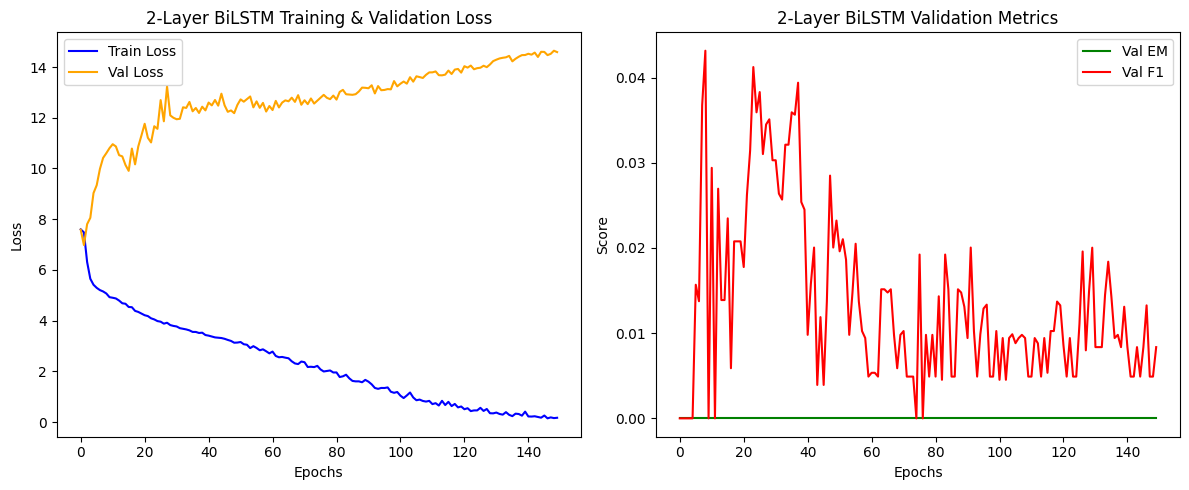

In [82]:
if len(file_list) > 0:
    EMB_DIM = 256
    HID_DIM = 512

    attn = Attention(HID_DIM).to(device)
    enc = BiLSTMEncoder(VOCAB_SIZE, EMB_DIM, HID_DIM, dropout=0.3).to(device)
    dec = DecoderRNN(VOCAB_SIZE, EMB_DIM, HID_DIM, attn, dropout=0.3).to(device)
    bilstm_model = Seq2Seq(enc, dec, device).to(device)
    bilstm_model.apply(init_weights)

    optimizer = optim.Adam(bilstm_model.parameters(), lr=0.0005, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])

    rnn_train_losses = []
    rnn_val_losses = [] 
    rnn_val_ems = []    # Track Exact Match
    rnn_val_f1s = []    # Track F1-Score

    print("Starting 2-Layer BiLSTM training for 150 epochs...")
    for epoch in range(150):
        # 1. Train Pass
        train_loss = train(bilstm_model, train_loader, optimizer, criterion)
        rnn_train_losses.append(train_loss)
        
        # 2. Validation Pass
        bilstm_model.eval()
        val_loss = 0
        val_em_total = 0
        val_f1_total = 0
        total_samples = 0
        
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                
                # Forward pass (Teacher forcing turned off for pure evaluation)
                output = bilstm_model(src, tgt, teacher_forcing_ratio=0) 
                
                # --- Loss Calculation ---
                output_dim = output.shape[-1]
                output_flat = output[:, 1:].reshape(-1, output_dim)
                tgt_flat = tgt[:, 1:].reshape(-1)
                loss = criterion(output_flat, tgt_flat)
                val_loss += loss.item()
                
                # --- Metrics Calculation ---
                # Grab the most likely tokens and the targets (ignoring <SOS> at index 0)
                preds = output[:, 1:, :].argmax(dim=-1)
                targets = tgt[:, 1:]
                
                for b in range(preds.shape[0]):
                    # Decode IDs back to text
                    pred_text = normalize_arabic(vocab.decode(preds[b].tolist()))
                    tgt_text = normalize_arabic(vocab.decode(targets[b].tolist()))
                    
                    # Accumulate scores
                    val_em_total += exact_match(tgt_text, pred_text)
                    val_f1_total += f1_score(tgt_text, pred_text)
                    total_samples += 1
        
        # Averages for the epoch
        avg_val_loss = val_loss / len(val_loader)
        avg_val_em = val_em_total / total_samples
        avg_val_f1 = val_f1_total / total_samples
        
        rnn_val_losses.append(avg_val_loss)
        rnn_val_ems.append(avg_val_em)
        rnn_val_f1s.append(avg_val_f1)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch: {epoch+1:03} | Train Loss: {train_loss:.3f} | Val Loss: {avg_val_loss:.3f} | Val EM: {avg_val_em:.2f} | Val F1: {avg_val_f1:.2f}')

    # 3. Plotting Subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Loss Plot
    ax1.plot(rnn_train_losses, label="Train Loss", color='blue')
    ax1.plot(rnn_val_losses, label="Val Loss", color='orange')
    ax1.set_title("2-Layer BiLSTM Training & Validation Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend()
    
    # Metrics Plot
    ax2.plot(rnn_val_ems, label="Val EM", color='green')
    ax2.plot(rnn_val_f1s, label="Val F1", color='red')
    ax2.set_title("2-Layer BiLSTM Validation Metrics")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Score")
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "rnn_v2_loss_metrics.png")
    
    torch.save(bilstm_model.state_dict(), OUTPUT_DIR / "rnn_model_v2.pth")
    print("Training complete! Model and dual plots saved.")


--- RUNNING OPTIMIZED BILSTM ---
Early Stopping at Epoch 21!
Optimized BiLSTM complete!


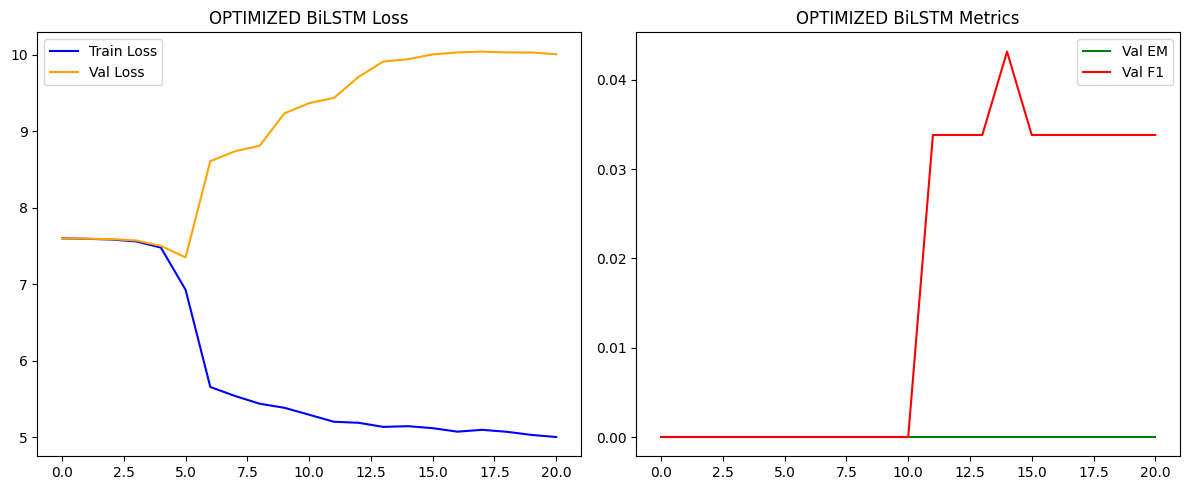

In [80]:
import copy

if len(file_list) > 0:
    print("\n--- RUNNING OPTIMIZED BILSTM ---")
    # Small Brain, High Regularization
    EMB_DIM = 64     
    HID_DIM = 128    

    attn = Attention(HID_DIM).to(device)
    enc = BiLSTMEncoder(VOCAB_SIZE, EMB_DIM, HID_DIM, dropout=0.5).to(device)
    dec = DecoderRNN(VOCAB_SIZE, EMB_DIM, HID_DIM, attn, dropout=0.5).to(device)
    bilstm_opt = Seq2Seq(enc, dec, device).to(device)
    bilstm_opt.apply(init_weights)

    # Heavier weight decay
    optimizer = optim.Adam(bilstm_opt.parameters(), lr=0.0005, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])

    train_losses, val_losses, val_ems, val_f1s = [], [], [], []
    best_val_loss = float('inf')
    patience, patience_counter = 15, 0
    best_weights = None

    for epoch in range(150):
        train_loss = train(bilstm_opt, train_loader, optimizer, criterion)
        train_losses.append(train_loss)
        
        bilstm_opt.eval()
        val_loss, val_em_total, val_f1_total, total_samples = 0, 0, 0, 0
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                output = bilstm_opt(src, tgt, teacher_forcing_ratio=0) 
                
                output_dim = output.shape[-1]
                val_loss += criterion(output[:, 1:].reshape(-1, output_dim), tgt[:, 1:].reshape(-1)).item()
                
                preds = output[:, 1:, :].argmax(dim=-1)
                targets = tgt[:, 1:]
                for b in range(preds.shape[0]):
                    pred_text = normalize_arabic(vocab.decode(preds[b].tolist()))
                    tgt_text = normalize_arabic(vocab.decode(targets[b].tolist()))
                    val_em_total += exact_match(tgt_text, pred_text)
                    val_f1_total += f1_score(tgt_text, pred_text)
                    total_samples += 1
        
        avg_val = val_loss / len(val_loader)
        val_losses.append(avg_val)
        val_ems.append(val_em_total / total_samples)
        val_f1s.append(val_f1_total / total_samples)

        # Early Stopping
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            best_weights = copy.deepcopy(bilstm_opt.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early Stopping at Epoch {epoch+1}!")
            break

    bilstm_opt.load_state_dict(best_weights)

    # Plot & Save
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(train_losses, label="Train Loss", color='blue')
    ax1.plot(val_losses, label="Val Loss", color='orange')
    ax1.set_title("OPTIMIZED BiLSTM Loss")
    ax1.legend()
    ax2.plot(val_ems, label="Val EM", color='green')
    ax2.plot(val_f1s, label="Val F1", color='red')
    ax2.set_title("OPTIMIZED BiLSTM Metrics")
    ax2.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "rnn_opt_loss_metrics.png")
    torch.save(bilstm_opt.state_dict(), OUTPUT_DIR / "rnn_model_opt.pth")
    print("Optimized BiLSTM complete!")

Starting Transformer training for 200 epochs...
Epoch: 010 | Train Loss: 5.989 | Val Loss: 7.067 | Val EM: 0.00 | Val F1: 0.00
Epoch: 020 | Train Loss: 5.313 | Val Loss: 7.243 | Val EM: 0.00 | Val F1: 0.02
Epoch: 030 | Train Loss: 4.808 | Val Loss: 7.295 | Val EM: 0.00 | Val F1: 0.03
Epoch: 040 | Train Loss: 4.309 | Val Loss: 7.244 | Val EM: 0.00 | Val F1: 0.04
Epoch: 050 | Train Loss: 3.823 | Val Loss: 7.543 | Val EM: 0.00 | Val F1: 0.04
Epoch: 060 | Train Loss: 3.367 | Val Loss: 7.588 | Val EM: 0.00 | Val F1: 0.04
Epoch: 070 | Train Loss: 3.043 | Val Loss: 7.541 | Val EM: 0.00 | Val F1: 0.04
Epoch: 080 | Train Loss: 2.622 | Val Loss: 7.710 | Val EM: 0.00 | Val F1: 0.04
Epoch: 090 | Train Loss: 2.295 | Val Loss: 7.854 | Val EM: 0.00 | Val F1: 0.03
Epoch: 100 | Train Loss: 2.031 | Val Loss: 8.022 | Val EM: 0.00 | Val F1: 0.03
Epoch: 110 | Train Loss: 1.712 | Val Loss: 8.034 | Val EM: 0.00 | Val F1: 0.03
Epoch: 120 | Train Loss: 1.427 | Val Loss: 8.018 | Val EM: 0.00 | Val F1: 0.04
Epoc

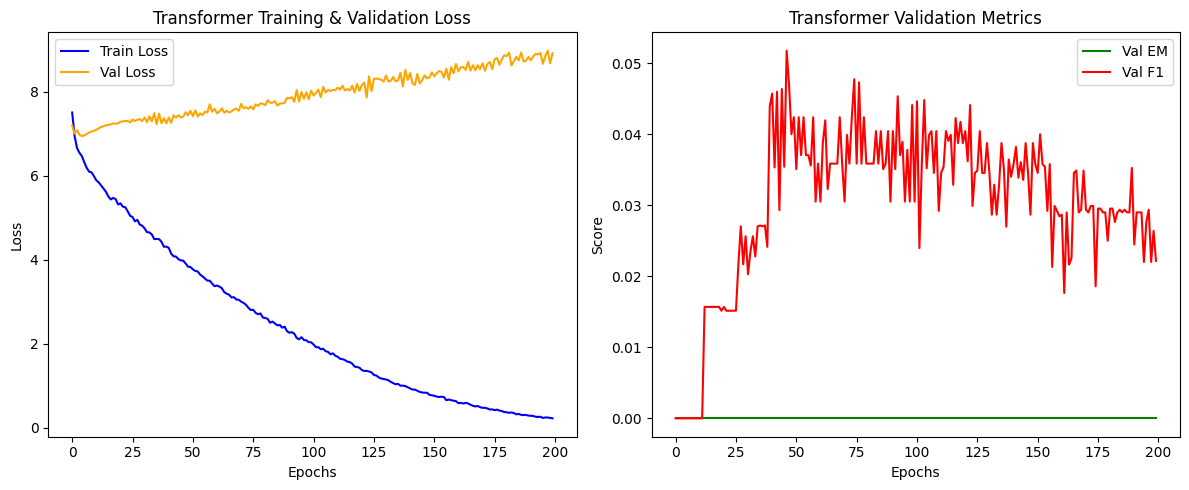

In [83]:
if len(file_list) > 0:
    transformer_model = QATransformer(
        vocab_size=VOCAB_SIZE, 
        d_model=256, 
        nhead=8, 
        num_encoder_layers=3, 
        num_decoder_layers=3
    ).to(device)
    
    transformer_optimizer = optim.Adam(transformer_model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])
    
    trans_train_losses = []
    trans_val_losses = []
    trans_val_ems = []    # Track Exact Match
    trans_val_f1s = []    # Track F1-Score
    
    print("Starting Transformer training for 200 epochs...")
    for epoch in range(200):
        # 1. Train Pass
        train_loss = train_transformer(transformer_model, train_loader, transformer_optimizer, criterion, vocab.stoi["<PAD>"])
        trans_train_losses.append(train_loss)
        
        # 2. Validation Pass
        transformer_model.eval()
        val_loss = 0
        val_em_total = 0
        val_f1_total = 0
        total_samples = 0
        
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                
                # Prepare inputs and expected targets
                tgt_input = tgt[:, :-1]
                tgt_expected = tgt[:, 1:]
                
                # Forward pass
                output = transformer_model(src, tgt_input, vocab.stoi["<PAD>"])
                
                # --- Loss Calculation ---
                output_dim = output.shape[-1]
                output_flat = output.reshape(-1, output_dim)
                tgt_expected_flat = tgt_expected.reshape(-1)
                loss = criterion(output_flat, tgt_expected_flat)
                val_loss += loss.item()
                
                # --- Metrics Calculation ---
                preds = output.argmax(dim=-1)
                
                for b in range(preds.shape[0]):
                    # Decode IDs back to text
                    pred_text = normalize_arabic(vocab.decode(preds[b].tolist()))
                    tgt_text = normalize_arabic(vocab.decode(tgt_expected[b].tolist()))
                    
                    # Accumulate scores
                    val_em_total += exact_match(tgt_text, pred_text)
                    val_f1_total += f1_score(tgt_text, pred_text)
                    total_samples += 1
                    
        # Averages for the epoch
        avg_val_loss = val_loss / len(val_loader)
        avg_val_em = val_em_total / total_samples
        avg_val_f1 = val_f1_total / total_samples
        
        trans_val_losses.append(avg_val_loss)
        trans_val_ems.append(avg_val_em)
        trans_val_f1s.append(avg_val_f1)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch: {epoch+1:03} | Train Loss: {train_loss:.3f} | Val Loss: {avg_val_loss:.3f} | Val EM: {avg_val_em:.2f} | Val F1: {avg_val_f1:.2f}')
            
    # 3. Plotting Subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Loss Plot
    ax1.plot(trans_train_losses, label="Train Loss", color='blue')
    ax1.plot(trans_val_losses, label="Val Loss", color='orange')
    ax1.set_title("Transformer Training & Validation Loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend()
    
    # Metrics Plot
    ax2.plot(trans_val_ems, label="Val EM", color='green')
    ax2.plot(trans_val_f1s, label="Val F1", color='red')
    ax2.set_title("Transformer Validation Metrics")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Score")
    ax2.legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "transformer_loss_metrics.png")
    
    torch.save(transformer_model.state_dict(), OUTPUT_DIR / "transformer_model.pth")
    print("Training complete! Model and dual plots saved.")


--- RUNNING OPTIMIZED TRANSFORMER ---
Early Stopping at Epoch 42!
Optimized Transformer complete!


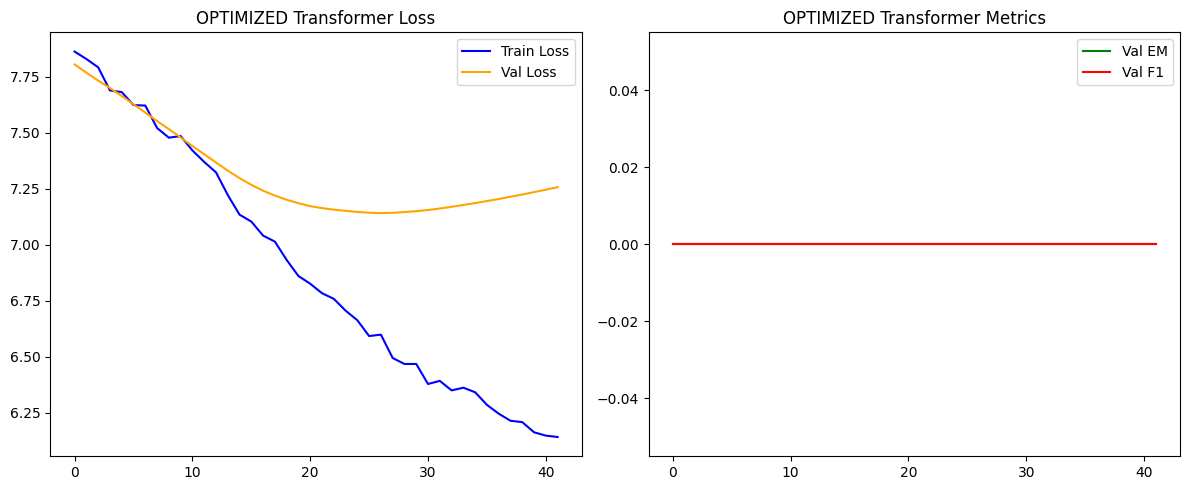

In [81]:
if len(file_list) > 0:
    print("\n--- RUNNING OPTIMIZED TRANSFORMER ---")
    trans_opt = QATransformer(
        vocab_size=VOCAB_SIZE, d_model=64, nhead=4, 
        num_encoder_layers=2, num_decoder_layers=2, dropout=0.3
    ).to(device)
    
    optimizer = optim.Adam(trans_opt.parameters(), lr=0.0001, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])
    
    train_losses, val_losses, val_ems, val_f1s = [], [], [], []
    best_val_loss = float('inf')
    patience, patience_counter = 15, 0
    best_weights = None
    
    for epoch in range(200):
        train_loss = train_transformer(trans_opt, train_loader, optimizer, criterion, vocab.stoi["<PAD>"])
        train_losses.append(train_loss)
        
        trans_opt.eval()
        val_loss, val_em_total, val_f1_total, total_samples = 0, 0, 0, 0
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                output = trans_opt(src, tgt[:, :-1], vocab.stoi["<PAD>"])
                
                output_dim = output.shape[-1]
                val_loss += criterion(output.reshape(-1, output_dim), tgt[:, 1:].reshape(-1)).item()
                preds = output.argmax(dim=-1)
                
                for b in range(preds.shape[0]):
                    pred_text = normalize_arabic(vocab.decode(preds[b].tolist()))
                    tgt_text = normalize_arabic(vocab.decode(tgt[:, 1:][b].tolist()))
                    val_em_total += exact_match(tgt_text, pred_text)
                    val_f1_total += f1_score(tgt_text, pred_text)
                    total_samples += 1
                    
        avg_val = val_loss / len(val_loader)
        val_losses.append(avg_val)
        val_ems.append(val_em_total / total_samples)
        val_f1s.append(val_f1_total / total_samples)
            
        # Early Stopping
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            best_weights = copy.deepcopy(trans_opt.state_dict())
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            print(f"Early Stopping at Epoch {epoch+1}!")
            break
            
    trans_opt.load_state_dict(best_weights)
            
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(train_losses, label="Train Loss", color='blue')
    ax1.plot(val_losses, label="Val Loss", color='orange')
    ax1.set_title("OPTIMIZED Transformer Loss")
    ax1.legend()
    ax2.plot(val_ems, label="Val EM", color='green')
    ax2.plot(val_f1s, label="Val F1", color='red')
    ax2.set_title("OPTIMIZED Transformer Metrics")
    ax2.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "transformer_opt_loss_metrics.png")
    torch.save(trans_opt.state_dict(), OUTPUT_DIR / "transformer_model_opt.pth")
    print("Optimized Transformer complete!")

In [84]:
test_file_list = list(DATA_DIR.glob('*_test_set.json'))
if len(test_file_list) > 0:
    print(f"Found {len(test_file_list)} test files.")
    test_dataset = ArabicQADataset(test_file_list, vocab, max_len=100, is_train=False)

    def evaluate_on_test_set(model, dataset, vocab, device, is_transformer=True, num_samples=None):
        total_em, total_f1 = 0, 0
        num_samples = len(dataset.data) if num_samples is None else min(num_samples, len(dataset.data))
        print(f"Evaluating {num_samples} samples...\n")
        
        indices = list(range(len(dataset.data)))
        random.shuffle(indices)
        
        for i in range(num_samples):
            idx = indices[i]
            question, context, reference_answer = dataset.data[idx]
            
            if is_transformer:
                predicted_answer = generate_answer_transformer(question, context, model, vocab, device)
            else:
                predicted_answer = generate_answer(question, context, model, vocab, device)
                
            ref_norm = normalize_arabic(reference_answer)
            pred_norm = normalize_arabic(predicted_answer)
            
            em = exact_match(ref_norm, pred_norm)
            f1 = f1_score(ref_norm, pred_norm)
            total_em += em
            total_f1 += f1
            
            if i < 3:
                print(f"--- Sample {i+1} ---")
                print(f"Question: {question}")
                print(f"Reference: {ref_norm}")
                print(f"Predicted: {pred_norm}")
                print(f"Scores -> EM: {em} | F1: {f1:.2f}\n")
                
        avg_em = total_em / num_samples
        avg_f1 = total_f1 / num_samples
        
        print("="*40)
        print(f"FINAL RESULTS ({num_samples} Samples)")
        print(f"Average Exact Match (EM) : {avg_em * 100:.2f}%")
        print(f"Average F1-Score         : {avg_f1 * 100:.2f}%")
        print("="*40)
        return avg_em, avg_f1

    print("\n--- Evaluating Transformer ---")
    transformer_model.eval()
    transformer_em, transformer_f1 = evaluate_on_test_set(
        transformer_model, test_dataset, vocab, device, is_transformer=True
    )

    print("\n--- Evaluating 2-Layer BiLSTM ---")
    bilstm_model.eval()
    rnn_em, rnn_f1 = evaluate_on_test_set(
        bilstm_model, test_dataset, vocab, device, is_transformer=False
    )
else:
    print("No test datasets found.")

Found 7 test files.

--- Evaluating Transformer ---
Evaluating 72 samples...

--- Sample 1 ---
Question: ما التحول الذي حدث في وظيفه الساموراي مع تطور دورهم؟
Reference: تحولوا الي حراس شخصيين للاقطاعيين
Predicted: تحولوا الي حراس شخصيين للاقطاعيين
Scores -> EM: 1 | F1: 1.00

--- Sample 2 ---
Question: ما المعني الاصلي لكلمه ساموراي في اللغه اليابانيه؟
Reference: الذي يخدم
Predicted: الرخام الابيض
Scores -> EM: 0 | F1: 0.00

--- Sample 3 ---
Question: ما النتيجه التي توصل اليها زينون بخصوص تغير العالم؟
Reference: العالم حولنا ثابت، لا يتغير
Predicted: العالم حولنا ثابت، لا يتغير
Scores -> EM: 1 | F1: 1.00

FINAL RESULTS (72 Samples)
Average Exact Match (EM) : 45.83%
Average F1-Score         : 53.95%

--- Evaluating 2-Layer BiLSTM ---
Evaluating 72 samples...

--- Sample 1 ---
Question: ما التغير الذي طرا علي الساموراي في فتره ايدو؟
Reference: تحول الساموراي من محاربين الي موظفين بيروقراطيين
Predicted: الذكاء اداه للنجاه وليس علامه الذكاء اداه للنجاه وليس علامه الذكاء اداه للنجاه وليس عل